In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from sklearn.feature_selection import mutual_info_classif


In [29]:
df = pd.read_csv("../data/processed/development_processed_v1.csv")

In [30]:
source_label_dist = (
	df.groupby("source")["label"]
	.value_counts(normalize=True)
	.unstack()
	.fillna(0)
)

source_label_dist.head()


label,0,1,2,3,4,5,6
source,,,,,,,
123Bharath.com,0.142857,0.000000,0.000000,0.00,0.285714,0.428571,0.142857
2TheAdvocate,0.000000,0.000000,0.000000,0.00,1.000000,0.000000,0.000000
365Gay.com,0.000000,0.000000,0.000000,0.25,0.000000,0.500000,0.250000
4TheGame,0.000000,0.000000,0.000000,0.00,1.000000,0.000000,0.000000
4ni.co.uk,0.285714,0.142857,0.142857,0.00,0.000000,0.285714,0.142857


In [31]:
# Contingency table
source_label_counts = (
	df
	.groupby(["source", "label"])
	.size()
	.unstack(fill_value=0)
)

# Normalize per source
source_label_prob = source_label_counts.div(
	source_label_counts.sum(axis=1),
	axis=0
)

# Sort sources by entropy (più informative sopra)
entropy = -(source_label_prob * np.log(source_label_prob + 1e-12)).sum(axis=1)
source_label_prob["entropy"] = entropy

source_label_prob = source_label_prob.sort_values("entropy")

print(source_label_prob.head(10))


label            0    1    2    3    4    5    6       entropy
source                                                        
Accra          0.0  1.0  0.0  0.0  0.0  0.0  0.0 -1.000089e-12
Ann            0.0  0.0  1.0  0.0  0.0  0.0  0.0 -1.000089e-12
Animation      0.0  0.0  1.0  0.0  0.0  0.0  0.0 -1.000089e-12
AngolaPress    1.0  0.0  0.0  0.0  0.0  0.0  0.0 -1.000089e-12
ABC12.com      0.0  0.0  0.0  0.0  1.0  0.0  0.0 -1.000089e-12
Mobilemag.com  0.0  0.0  1.0  0.0  0.0  0.0  0.0 -1.000089e-12
Mmegi          0.0  0.0  0.0  0.0  0.0  1.0  0.0 -1.000089e-12
Mirror.co.uk   0.0  0.0  0.0  0.0  1.0  0.0  0.0 -1.000089e-12
Minnesota      0.0  0.0  0.0  0.0  0.0  1.0  0.0 -1.000089e-12
Mineweb        0.0  1.0  0.0  0.0  0.0  0.0  0.0 -1.000089e-12


In [33]:
# Rimuoviamo entropy
prior_table = source_label_prob.drop(columns=["entropy"])

# Normalizzazione di sicurezza
prior_table = prior_table.div(prior_table.sum(axis=1), axis=0)

# Convert to dict
source_prior = prior_table.to_dict(orient="index")

# Default prior (se source mai vista)
global_prior = df["label"].value_counts(normalize=True).sort_index().values


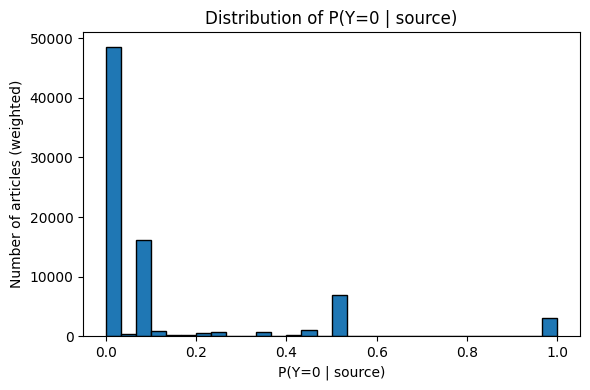

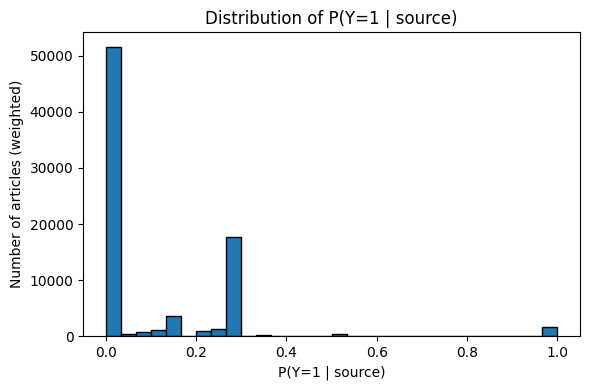

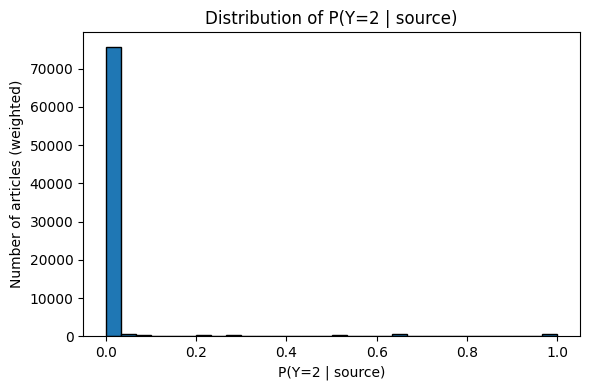

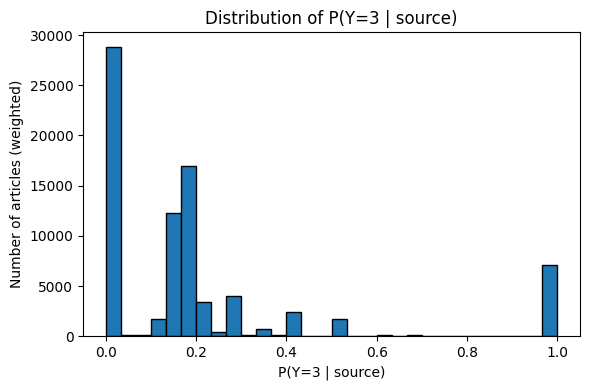

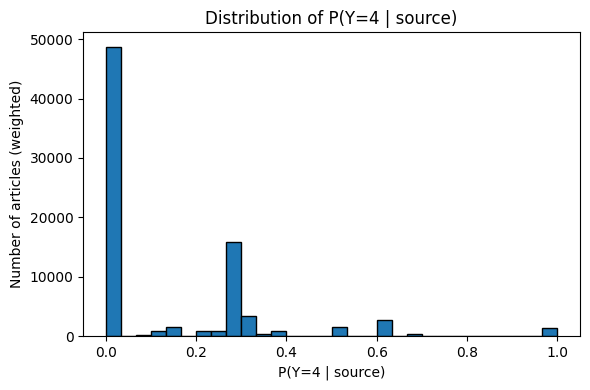

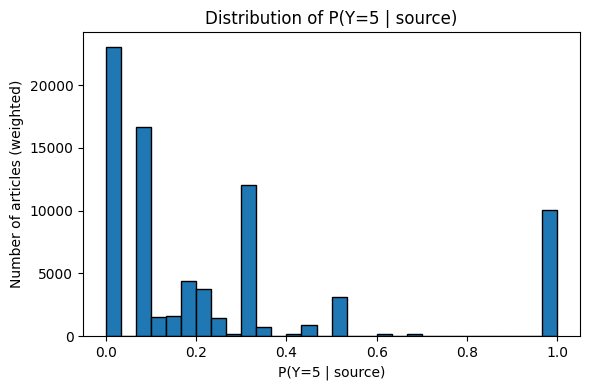

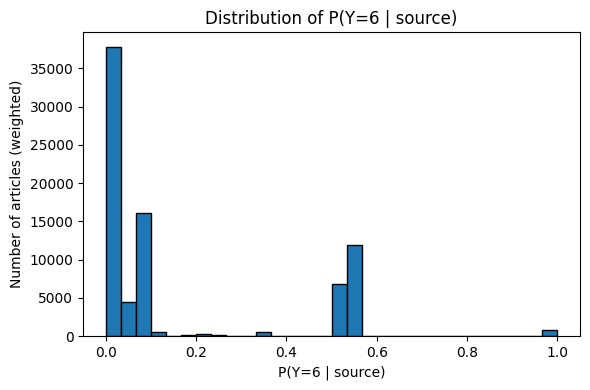

In [34]:
labels = source_label_prob.columns.drop(["entropy", "entropy_norm", "determinism_class"], errors="ignore")

for y in labels:
	plt.figure(figsize=(6,4))
	plt.hist(
		source_label_prob[y],
		bins=30,
		weights=source_label_counts.sum(axis=1),
		edgecolor="black"
	)
	plt.title(f"Distribution of P(Y={y} | source)")
	plt.xlabel(f"P(Y={y} | source)")
	plt.ylabel("Number of articles (weighted)")
	plt.tight_layout()
	plt.show()

In [35]:
labels = source_label_prob.columns.drop(
	["entropy", "entropy_norm", "determinism_class"],
	errors="ignore"
)

rows = []

for y in labels:
	col = source_label_prob[y]

	rows.append({
		"label": y,
		"min": col.min(),
		"p10": col.quantile(0.10),
		"p25": col.quantile(0.25),
		"median": col.quantile(0.50),
		"p75": col.quantile(0.75),
		"p90": col.quantile(0.90),
		"max": col.max()
	})

label_prior_summary = pd.DataFrame(rows).set_index("label")
label_prior_summary


,min,p10,p25,median,p75,p90,max
label,,,,,,,
0,0.0,0.0,0.0,0.000000,0.065225,0.413768,1.0
1,0.0,0.0,0.0,0.000000,0.090909,0.333333,1.0
2,0.0,0.0,0.0,0.000000,0.034259,0.500000,1.0
3,0.0,0.0,0.0,0.086957,0.333333,1.000000,1.0
4,0.0,0.0,0.0,0.000000,0.200000,0.666667,1.0
5,0.0,0.0,0.0,0.000000,0.306020,0.500000,1.0
6,0.0,0.0,0.0,0.000000,0.000000,0.250000,1.0


In [36]:
rows = []

for y in labels:
	p90 = source_label_prob[y].quantile(0.90)
	p95 = source_label_prob[y].quantile(0.95)

	rows.append({
		"label": y,
		"n_sources_p>p90": (source_label_prob[y] > p90).sum(),
		"n_sources_p>p95": (source_label_prob[y] > p95).sum(),
		"p90_value": p90,
		"p95_value": p95
	})

high_conf_sources = pd.DataFrame(rows).set_index("label")
high_conf_sources


,n_sources_p>p90,n_sources_p>p95,p90_value,p95_value
label,,,,
0,136,68,0.413768,0.626786
1,124,68,0.333333,0.750139
2,135,0,0.500000,1.000000
3,0,0,1.000000,1.000000
4,134,0,0.666667,1.000000
5,130,0,0.500000,1.000000
6,130,66,0.250000,0.500000


In [37]:
rows = []

for y in labels:
	p90 = source_label_prob[y].quantile(0.90)

	high_sources = source_label_prob.index[
		source_label_prob[y] > p90
	]

	coverage = source_label_counts.loc[
		high_sources
	].sum().sum() / source_label_counts.sum().sum()

	rows.append({
		"label": y,
		"article_coverage_p90": coverage
	})

coverage_table = pd.DataFrame(rows).set_index("label")
coverage_table


,article_coverage_p90
label,
0,0.333037
1,0.040227
2,0.102254
3,0.000000
4,0.011513
5,0.055315
6,0.005675


In [38]:
prior_features = []

for y in labels:
	prior_features.extend([
		f"source_prior_{y}",
		f"source_highconf_{y}"
	])

pd.DataFrame({
	"feature_name": prior_features,
	"type": ["continuous", "binary"] * len(labels)
})


,feature_name,type
0,source_prior_0,continuous
1,source_highconf_0,binary
2,source_prior_1,continuous
3,source_highconf_1,binary
4,source_prior_2,continuous
5,source_highconf_2,binary
6,source_prior_3,continuous
7,source_highconf_3,binary
8,source_prior_4,continuous
9,source_highconf_4,binary


In [42]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("../data/raw/development.csv ")

df.columns

Index(['Id', 'source', 'title', 'article', 'page_rank', 'timestamp', 'label'], dtype='object')

In [43]:
url_pattern = re.compile(r"https?://\S+")

df["n_links"] = df["article"].apply(
	lambda x: len(url_pattern.findall(x)) if isinstance(x, str) else 0
)

In [44]:
df["n_links"].head()

0    0
1    0
2    0
3    0
4    2
Name: n_links, dtype: int64

In [45]:
df["log_n_links"] = np.log1p(df["n_links"])


In [46]:
link_stats = (
	df
	.groupby("label")["log_n_links"]
	.describe(percentiles=[0.25, 0.5, 0.75, 0.9])
)

link_stats

,count,mean,std,min,25%,50%,75%,90%,max
label,,,,,,,,,
0,23542.0,0.216923,0.468464,0.0,0.0,0.0,0.0,1.098612,3.367296
1,10588.0,0.164189,0.425172,0.0,0.0,0.0,0.0,1.098612,2.564949
2,11161.0,0.355149,0.755471,0.0,0.0,0.0,0.0,1.609438,4.043051
3,9977.0,0.153259,0.443447,0.0,0.0,0.0,0.0,1.098612,4.189655
4,8574.0,0.133792,0.366390,0.0,0.0,0.0,0.0,1.098612,2.302585
5,13053.0,0.154866,0.469182,0.0,0.0,0.0,0.0,0.693147,2.639057
6,3102.0,0.069150,0.294855,0.0,0.0,0.0,0.0,0.000000,2.302585


In [47]:
from sklearn.feature_selection import mutual_info_classif

MI_links = mutual_info_classif(
	df[["log_n_links"]],
	df["label"],
	discrete_features=False,
	random_state=42
)[0]

MI_links


np.float64(0.05933579376248632)

In [48]:
df.groupby("source")["n_links"].mean().describe()


count    1359.000000
mean        0.031865
std         0.434791
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.012903
Name: n_links, dtype: float64

In [49]:
df.head()

,Id,source,title,article,page_rank,timestamp,label,n_links,log_n_links
0,0,AllAfrica.com,OPEC Boosts Nigeria&#39;s Oil Revenue By .82m Bpd,THE Organisation of Petroleum Exporting Countr...,5,2004-09-16 22:39:53,5,0,0.000000
1,1,Xinhua,Yearender: Mideast peace roadmap reaches dead-...,Looking back at the major events that took pla...,5,2004-12-17 19:01:14,0,0,0.000000
2,2,Yahoo,Battleground Dispatches for Oct. 5 \\n (CQP...,CQPolitics.com - Here are today's Battleground...,5,2006-10-05 18:42:29,0,0,0.000000
3,3,BBC,Air best to resuscitate newborns,Air rather than oxygen should be used to resus...,5,0000-00-00 00:00:00,0,0,0.000000
4,4,Yahoo,High tech German train crash kills at least on...,"<p><a href=""http://us.rd.yahoo.com/dailynews/r...",5,2006-09-22 17:28:57,0,2,1.098612


In [50]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer


In [51]:
X = df[["log_n_links"]]
y = df["label"]

pipe = Pipeline([
	("scaler", StandardScaler()),
	("clf", LogisticRegression(
		multi_class="multinomial",
		max_iter=1000,
		class_weight="balanced",
		random_state=42
	))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
	pipe,
	X,
	y,
	cv=cv,
	scoring=make_scorer(f1_score, average="macro")
)

print("Fold scores:", scores)
print("Mean macro-F1:", scores.mean())


C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_mo

Fold scores: [0.04085404 0.03970193 0.03966759 0.04019336 0.04122746]
Mean macro-F1: 0.04032887705275122


C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [52]:
df["article_len"] = df["article"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df["title_len"] = df["title"].apply(lambda x: len(x) if isinstance(x, str) else 0)

df["log_article_len"] = np.log1p(df["article_len"])
df["log_title_len"] = np.log1p(df["title_len"])

In [53]:
X = df[[
	"log_n_links",
	"log_article_len",
	"log_title_len",
	"page_rank"      # solo per questo test
]]

y = df["label"]


In [54]:
pipe = Pipeline([
	("scaler", StandardScaler()),
	("clf", LogisticRegression(
		multi_class="multinomial",
		max_iter=1000,
		class_weight="balanced",
		random_state=42
	))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
	pipe,
	X,
	y,
	cv=cv,
	scoring=make_scorer(f1_score, average="macro")
)

scores, scores.mean()


C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_mo

(array([0.21566923, 0.21952218, 0.22202389, 0.2151506 , 0.2220389 ]),
 np.float64(0.21888096036788834))

In [64]:
dataset_token = pd.read_csv("../data/processed/development_v1.csv")
df_struct = df[["Id", "log_n_links"]].copy()



In [65]:
df_links = df[["Id", "log_n_links"]].copy()

In [66]:
dataset_token.columns

Index(['Id', 'text', 'source', 'title', 'n_tokens', 'title_ratio', 'year',
       'month', 'has_timestamp', 'label'],
      dtype='object')

In [67]:
# Id univoci
assert dataset_token["Id"].is_unique
assert df_links["Id"].is_unique

# Overlap completo
print(
	len(dataset_token),
	len(df_links),
	len(set(dataset_token["Id"]).intersection(df_links["Id"]))
)


79997 79997 79997


In [68]:
dataset_token = dataset_token.merge(
	df_links,
	on="Id",
	how="left"
)


In [69]:
dataset_token.columns


Index(['Id', 'text', 'source', 'title', 'n_tokens', 'title_ratio', 'year',
       'month', 'has_timestamp', 'label', 'log_n_links'],
      dtype='object')

In [79]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer

# =========================
# FIX NaN NEL TESTO (CRITICO)
# =========================

dataset_token["text"] = dataset_token["text"].fillna("")
dataset_token = dataset_token.dropna(
	subset=["n_tokens", "title_ratio"]
).reset_index(drop=True)

# =========================
# TARGET
# =========================

y = dataset_token["label"]

numeric_features = [
	"n_tokens",
	"title_ratio",
	"year",
	"month",
	"has_timestamp",
	"log_n_links"
]

# =========================
# PREPROCESSING
# =========================

tfidf = TfidfVectorizer(
	max_features=50000,
	ngram_range=(1, 2),
	min_df=5
)

preprocess = ColumnTransformer(
	transformers=[
		("num", StandardScaler(), numeric_features),
		("text", tfidf, "text")
	],
	remainder="drop"
)

# =========================
# MODEL
# =========================

model = LogisticRegression(
	multi_class="multinomial",
	max_iter=1000,
	class_weight="balanced",
	n_jobs=-1
)

pipe = Pipeline([
	("prep", preprocess),
	("clf", model)
])

# =========================
# CROSS-VALIDATION
# =========================

cv = StratifiedKFold(
	n_splits=5,
	shuffle=True,
	random_state=42
)

scores = cross_val_score(
	pipe,
	dataset_token,
	y,
	cv=cv,
	scoring=make_scorer(f1_score, average="macro")
)

print("Fold scores:", scores)
print("Mean macro-F1:", scores.mean())



C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\msist\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_mo

Fold scores: [0.64428183 0.64315968 0.64200091 0.64154111 0.64384576]
Mean macro-F1: 0.6429658571081915


Adding a structural feature capturing hyperlink density (log_n_links) to the text-based model yields a consistent improvement of approximately 2 percentage points in macro-F1 score (from ~0.62 to ~0.643).
This indicates that editorial structure provides complementary information beyond lexical content.

In [80]:
import numpy as np
import pandas as pd

# =========================
# SOURCE → LABEL DISTRIBUTION
# =========================

# Contingency table
source_label_counts = (
	dataset_token
	.groupby(["source", "label"])
	.size()
	.unstack(fill_value=0)
)

# Probabilità p(label | source)
source_label_prob = source_label_counts.div(
	source_label_counts.sum(axis=1),
	axis=0
)

# =========================
# FEATURE 1: ENTROPY
# =========================

source_entropy = -(
	source_label_prob * np.log(source_label_prob + 1e-12)
).sum(axis=1)

# =========================
# FEATURE 2: MAX PRIOR
# =========================

source_max_prior = source_label_prob.max(axis=1)

# =========================
# FEATURE 3: SUPPORT
# =========================

source_support = source_label_counts.sum(axis=1)

# =========================
# MERGE FEATURES
# =========================

source_features = pd.DataFrame({
	"source": source_entropy.index,
	"source_entropy": source_entropy.values,
	"source_max_prior": source_max_prior.values,
	"source_support": source_support.values
})

dataset_token = dataset_token.merge(
	source_features,
	on="source",
	how="left"
)

# =========================
# SANITY CHECK
# =========================

dataset_token[[
	"source_entropy",
	"source_max_prior",
	"source_support"
]].describe()


,source_entropy,source_max_prior,source_support
count,7.999600e+04,79996.000000,79996.000000
mean,1.295168e+00,0.495512,6688.745537
std,5.167067e-01,0.235111,6069.460009
min,-1.000089e-12,0.197674,1.000000
25%,1.060724e+00,0.268065,590.000000
50%,1.410027e+00,0.531483,6430.000000
75%,1.727295e+00,0.552126,11915.000000
max,1.850377e+00,1.000000,15850.000000


In [81]:
numeric_features = [
	"n_tokens",
	"title_ratio",
	"year",
	"month",
	"has_timestamp",
	"log_n_links",
	"source_entropy",
	"source_max_prior",
	"source_support"
]


In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer

# =========================
# TARGET
# =========================

y = dataset_token["label"]

# =========================
# PREPROCESSING
# =========================

tfidf = TfidfVectorizer(
	max_features=50000,
	ngram_range=(1, 2),
	min_df=5
)

preprocess = ColumnTransformer(
	transformers=[
		("num", StandardScaler(), numeric_features),
		("text", tfidf, "text")
	],
	remainder="drop"
)

# =========================
# MODEL
# =========================

model = LogisticRegression(
	max_iter=1000,
	class_weight="balanced",
	n_jobs=-1
)

pipe = Pipeline([
	("prep", preprocess),
	("clf", model)
])

# =========================
# CROSS-VALIDATION
# =========================

cv = StratifiedKFold(
	n_splits=5,
	shuffle=True,
	random_state=42
)

scores = cross_val_score(
	pipe,
	dataset_token,
	y,
	cv=cv,
	scoring=make_scorer(f1_score, average="macro")
)

print("Fold scores:", scores)
print("Mean macro-F1:", scores.mean())


Fold scores: [0.64754814 0.65058886 0.65215649 0.6489376  0.65052279]
Mean macro-F1: 0.6499507770981342


This is the best fold, I tried with other tags, they just lower the point 

In [83]:
dataset_token.columns

Index(['Id', 'text', 'source', 'title', 'n_tokens', 'title_ratio', 'year',
       'month', 'has_timestamp', 'label', 'log_n_links', 'source_entropy',
       'source_max_prior', 'source_support'],
      dtype='object')

In [90]:
dataset_token.to_csv(
	"../data/processed/v2/development_token_nohref_in_text.csv",
	index=False
)

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_analysis = df.copy()

df_analysis["log_page_rank"] = np.log1p(df_analysis["page_rank"])


c:\Users\msist\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


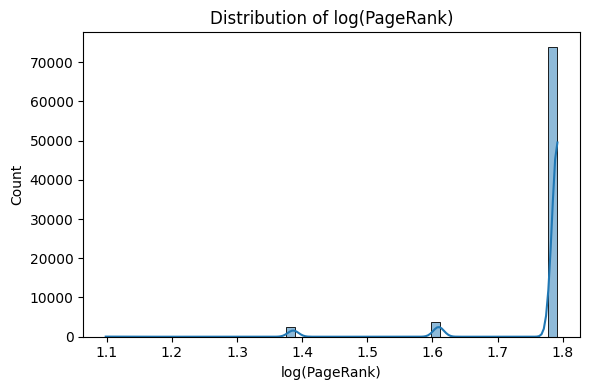

In [85]:
plt.figure(figsize=(6,4))
sns.histplot(df_analysis["log_page_rank"], bins=50, kde=True)
plt.title("Distribution of log(PageRank)")
plt.xlabel("log(PageRank)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


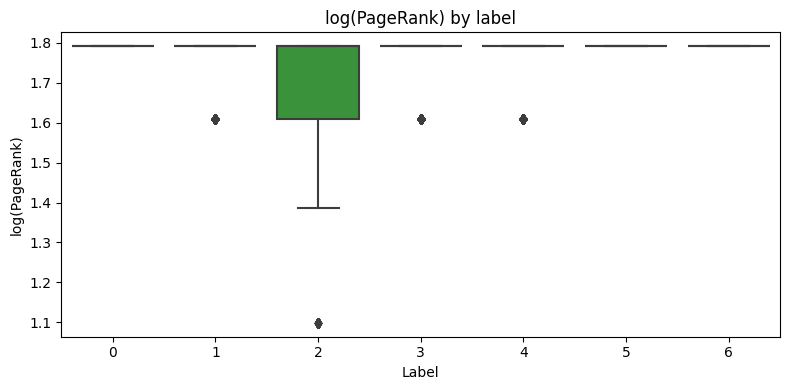

In [86]:
plt.figure(figsize=(8,4))
sns.boxplot(
	data=df_analysis,
	x="label",
	y="log_page_rank"
)
plt.title("log(PageRank) by label")
plt.xlabel("Label")
plt.ylabel("log(PageRank)")
plt.tight_layout()
plt.show()


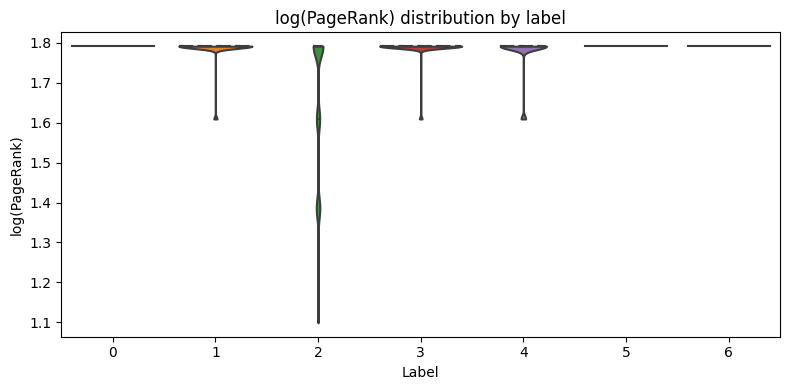

In [87]:
plt.figure(figsize=(8,4))
sns.violinplot(
	data=df_analysis,
	x="label",
	y="log_page_rank",
	inner="quartile",
	cut=0
)
plt.title("log(PageRank) distribution by label")
plt.xlabel("Label")
plt.ylabel("log(PageRank)")
plt.tight_layout()
plt.show()


In [88]:
df_analysis.groupby("label")["log_page_rank"].describe()


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23542.0,1.791759,2.220493e-16,1.791759,1.791759,1.791759,1.791759,1.791759
1,10588.0,1.784269,3.618982e-02,1.609438,1.791759,1.791759,1.791759,1.791759
2,11161.0,1.667538,1.667468e-01,1.098612,1.609438,1.791759,1.791759,1.791759
3,9977.0,1.785875,3.222285e-02,1.609438,1.791759,1.791759,1.791759,1.791759
4,8574.0,1.775450,5.203789e-02,1.609438,1.791759,1.791759,1.791759,1.791759
5,13053.0,1.791759,0.000000e+00,1.791759,1.791759,1.791759,1.791759,1.791759
6,3102.0,1.791759,2.220804e-16,1.791759,1.791759,1.791759,1.791759,1.791759


In [89]:
from sklearn.feature_selection import mutual_info_classif

X_pr = df_analysis[["log_page_rank"]]
y = df_analysis["label"]

mi_pr = mutual_info_classif(X_pr, y, discrete_features=False, random_state=42)
print("MI(log_page_rank, label):", mi_pr[0])


MI(log_page_rank, label): 0.11509182630312775
